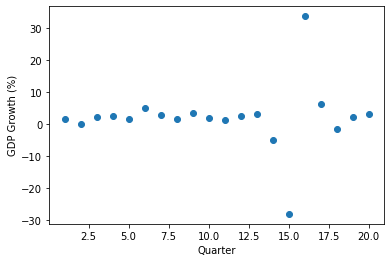

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1,21)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
plt.scatter(x,y)
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.show()

This scatter plot visualizes the data set provided by the U.S. Bureau of Economic Analysis, analyzing quarterly U.S. GDP growth from 2010 to 2023. In the data set, 20 of the 56 quarterly data points are included. Therefore, we will be applying 3 methods to interpolate the rest of the data: cublic spline interpolation, polynomial fitting, and least squares linear regression.

In [3]:
def setup_tridiagonal_matrix(x, y):
    
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i-1]
        B[i - 1] = 2*(h[i-1]+h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])
        
    return A, B, C, D

In [4]:
def thomas_algorithm(a, b, c, d):
    
    n = len(b)
   
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
  
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x